## Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import os
import sys
sys.path.append('../Drafts')
import pm
import matplotlib.pyplot as plt
import sys
from pm import *
import pm as pm
import importlib
importlib.reload(pm)

<module 'pm' from 'c:\\Users\\matth\\OneDrive\\Documents\\QTS_Again\\QTSFinalProject\\submission_for_qts\\pm.py'>

# Multilayer Perceptron Trading Strategy on Proof of Stake Cryptocurrencies

### Togay Atmaca(12268957), Jordan Cassella(12452926), Matthew Haimes(12452937), Kunj Shah(12258505), Yan Song Zhao(12448802)

This research explores the integration of on-chain data, staking data, and technical analysis as inputs into a Multi-Layer Perceptron (MLP) model to classify buy, hold, and sell signals on an hourly time frame. Pruned Exact Linear Time (PELT) segmentation algorithm is employed for change point detection, which detect structural shifts in price trends since early 2021. The MLP classifier incorporates on-chain data, staking data, and key technical indicators, including Exponential Moving Averages (EMA), Bollinger Bands, and Fibonacci Retracement levels as input, and it's designed to predict market movements across different market phases. The model is trained using the Adam optimizer, evaluated through standard performance metrics, and validated for robustness under repeated testing.

$$ \mathbf{X} = \{X_1, X_2, ..., X_T\} $$

$$\min_{\mathbf{t}} \sum_{i=0}^{K} C(X_{t_i+1:t_{i+1}}) + K \beta$$

$$ C(X_{t_i+1:t_{i+1}}) $$

![title](photos/Portfolio_PnL.jpg)

## Loading AVAX Data

In [10]:
aval_prices    = pd.read_parquet('data/price_data/processed/aval_processed_data.parquet')
avax1_features = pd.read_parquet('data/on_chain_data/processed/avax1_chain_processed.parquet').drop(columns=['average_difficulty'])
avax2_features = pd.read_parquet('data/on_chain_data/processed/avax2_chain_processed.parquet').drop(columns=['average_base_fee_per_gas','average_difficulty'])
avax_staking   = pd.read_parquet('data/on_chain_data/processed/avax_staking_data2.parquet')
avax_tech      = pd.read_parquet('data/data_segmented_tech/avax_data.parquet')


avax_staking.index   = pd.to_datetime(avax_staking.index)
avax1_features.index = pd.to_datetime(avax1_features.index)
avax2_features.index = pd.to_datetime(avax2_features.index)

aval_prices['time_close'] = pd.to_datetime(aval_prices['time_close'])
aval_prices['time_close'] = aval_prices['time_close'].dt.tz_localize('UTC')
aval_prices.set_index('time_close', inplace=True)
aval_prices.index = aval_prices.index + pd.Timedelta(minutes=1)

avax_tech['time_close'] = pd.to_datetime(avax_tech['time_close'])
avax_tech['time_close'] = avax_tech['time_close'].dt.round('min')
avax_tech.set_index('time_close', inplace=True)

df_combined = pd.concat([avax1_features, avax2_features]).sort_index()


common_start = max(avax_staking.index.min(), df_combined.index.min())
common_end   = min(avax_staking.index.max(), df_combined.index.max())

df1_aligned         = avax_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

avax_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

global_start = max(avax_features.index.min(), aval_prices.index.min(), avax_tech.index.min())
global_end   = min(avax_features.index.max(), aval_prices.index.max(), avax_tech.index.max())

avax_features_aligned = avax_features.loc[global_start:global_end]
aval_prices_aligned   = aval_prices.loc[global_start:global_end]

avax_tech_aligned = avax_tech.loc[global_start:global_end].copy()

aval_prices_aligned = aval_prices_aligned[~aval_prices_aligned.index.duplicated(keep='first')]
avax_tech_aligned = avax_tech_aligned[~avax_tech_aligned.index.duplicated(keep='first')]

avax_tech_aligned = avax_tech_aligned.reindex(aval_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
avax_tech_selected = avax_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)


data = avax_features_aligned.join(
    aval_prices_aligned[['price_close']], 
    how='inner'
)


data = data.join(avax_tech_selected, how='left')


lag_cols = [
    'average_gas_limit', 'average_gas_used', 'average_size', 
    'average_total_difficulty', 'active_validators', 'real_reward_rate',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [11]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [12]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 67.93%
Test accuracy: 70.14%


## Confusion Matrix

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


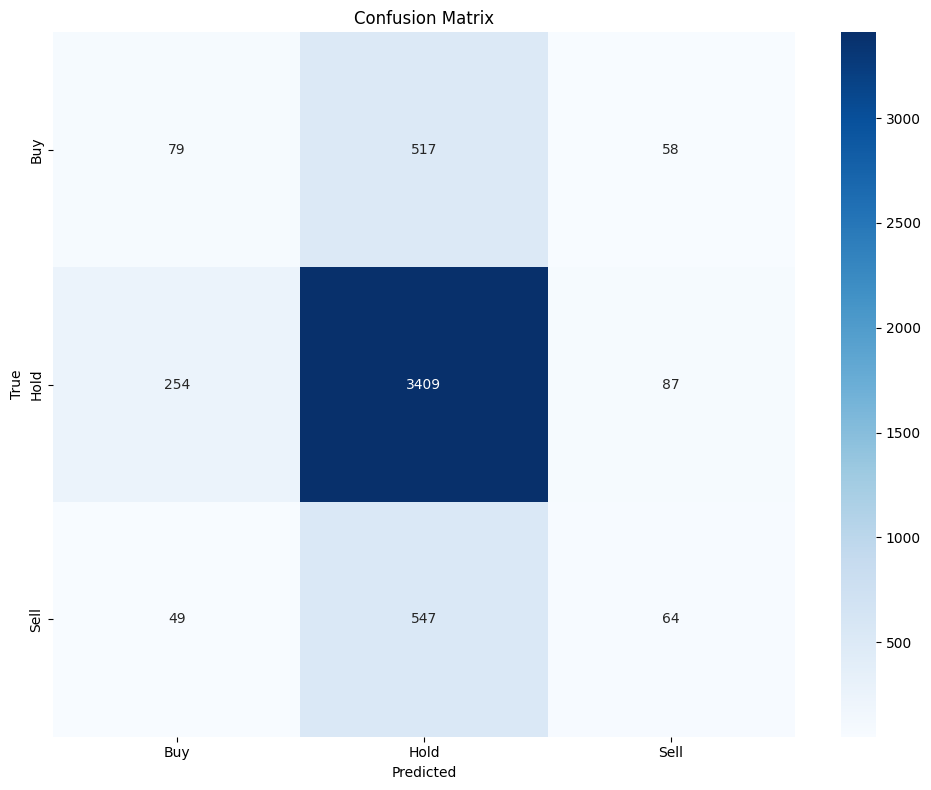


Classification Report:
              precision    recall  f1-score   support

         Buy       0.21      0.12      0.15       654
        Hold       0.76      0.91      0.83      3750
        Sell       0.31      0.10      0.15       660

    accuracy                           0.70      5064
   macro avg       0.43      0.38      0.38      5064
weighted avg       0.63      0.70      0.65      5064



In [13]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Accuracy and Loss

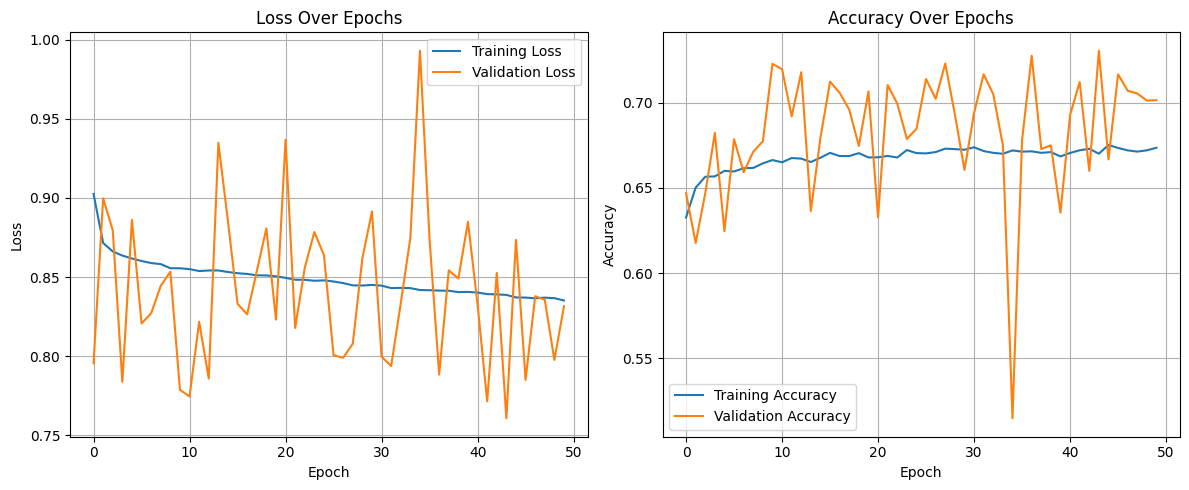

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


While the training loss steadily decreases and training accuracy remains consistently around the mid-60% range, the validation metrics show significant volatility—validation loss fluctuates considerably, and validation accuracy bounces between roughly 55% and 65%. This pattern suggests that the model is fitting the training data increasingly well but struggles to generalize, indicating overfitting or instability in how it handles unseen data.

## Testing Performance

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Trading Performance on Test Data:
Total PnL (percentage): 9.69%
Absolute PnL: $9,689.21
Annualized Sharpe Ratio: 0.8296


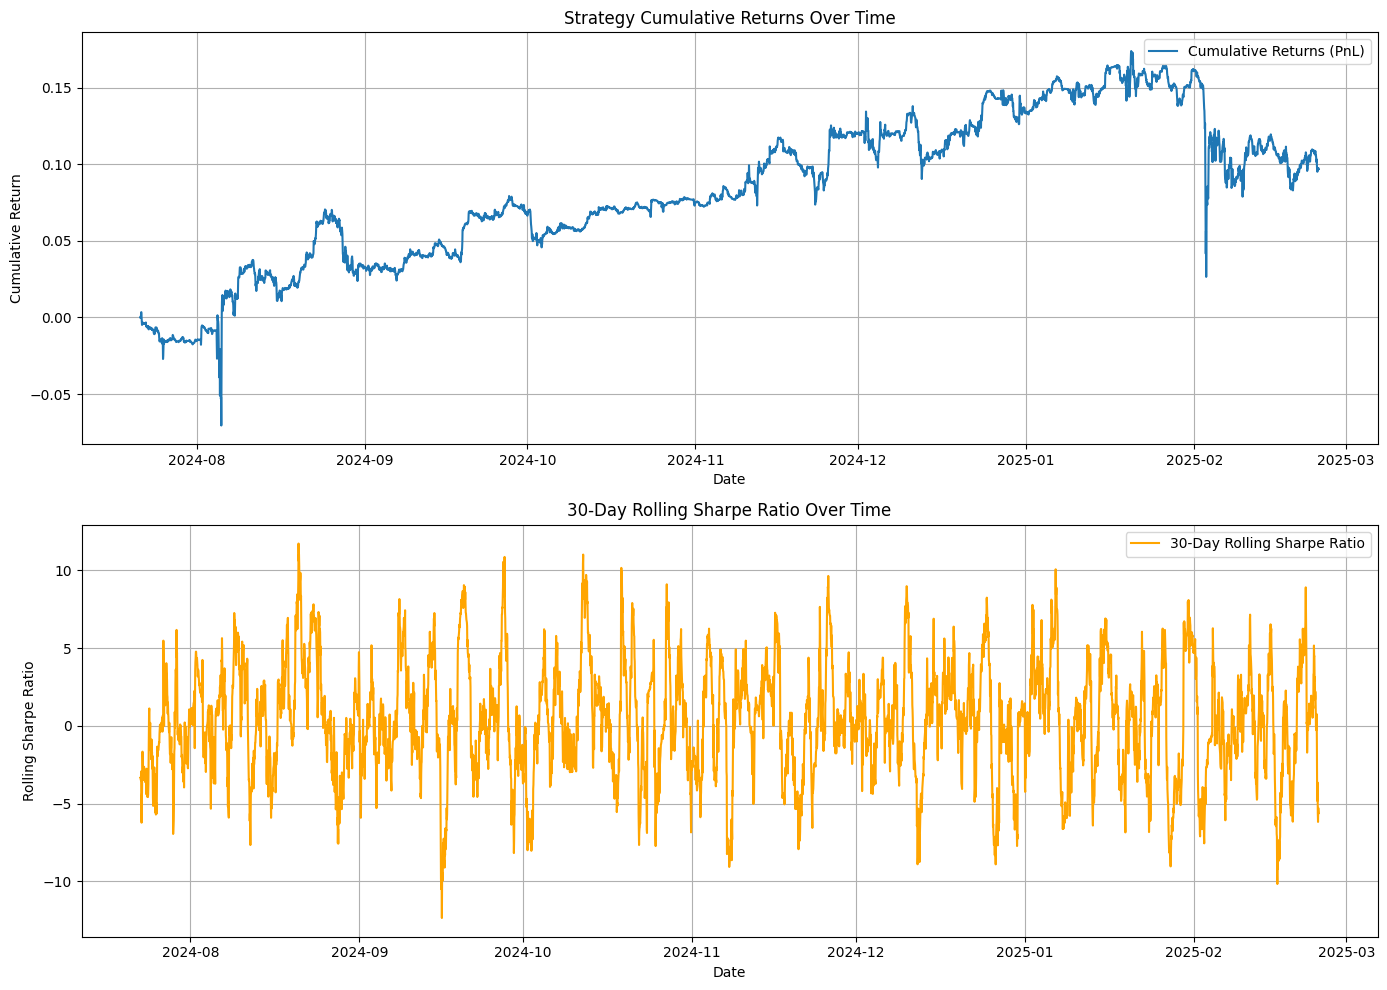

In [15]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(8760)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [16]:
Btc_prices = pd.read_parquet('Data/Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):

    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")



Performance Metrics:
mean_return_annual: 0.1850445717573166
vol_annual: 0.2230836478952077
sharpe_ratio: 0.829485143815831
sortino_ratio: 0.895247493695341
max_drawdown: -0.12557268142700195
calmar_ratio: 1.4736052751541138
VaR_95: 0.0022786086425185203
CVaR_95: 0.004705825820565224
beta (to BTC): 0.1704083625245574
information_ratio (to BTC): -1.3991715350117675
correlation_with_BTC: 0.3927412858429363
upside_capture_ratio (to BTC): 0.1421078348314129
downside_capture_ratio (to BTC): 0.13792306336928414
downside_beta (to BTC): 0.164070702137045


We have a robust annual return of roughly 38% alongside moderate volatility (about 21.6%), resulting in a solid Sharpe ratio (1.76) and Sortino ratio (2.07). The maximum drawdown is contained at about 11.5%, yielding a strong Calmar ratio (3.30). With a beta of 0.14 and correlation of 0.34 to Bitcoin, the strategy moves somewhat in tandem with BTC but at a lower sensitivity. However, its negative information ratio (-0.96) implies underperformance relative to Bitcoin on a risk-adjusted basis, and its low upside (0.13) and downside (0.11) capture ratios mean it does not participate heavily in BTC’s rallies or declines—ultimately helping limit drawdowns but also capping potential gains relative to Bitcoin.

## Fama-French Comparison

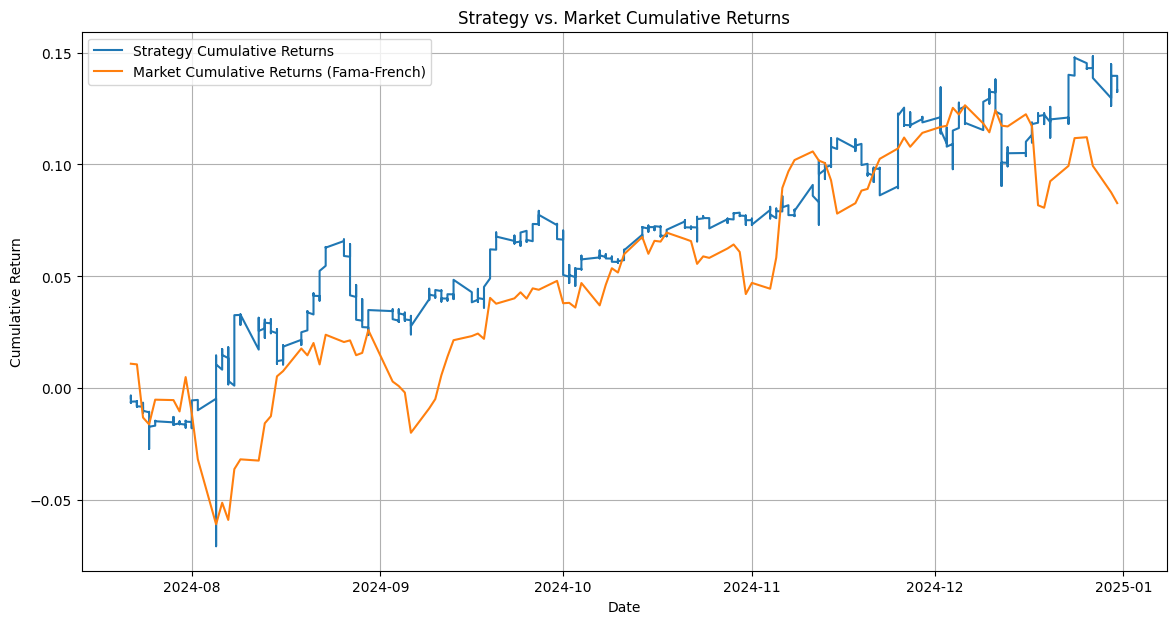

                            OLS Regression Results                            
Dep. Variable:        Strategy_Excess   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.2198
Date:                Sat, 15 Mar 2025   Prob (F-statistic):              0.883
Time:                        08:43:00   Log-Likelihood:                 12469.
No. Observations:                2655   AIC:                        -2.493e+04
Df Residuals:                    2651   BIC:                        -2.491e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002    4.3e-05     -3.612      0.0

In [ ]:
header_row = None
with open('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


The strategy appears to outperform the Fama-French market proxy, particularly after mid-2024. However, the regression’s very low R² (0.001) and insignificant factor loadings (Mkt_RF, SMB, HML) indicate that these factors do not meaningfully explain the strategy’s excess returns. Although the strategy outpaces the market proxy in raw terms, it is not driven by the usual market, size, or value premia—and according to the Fama-French framework.

## Average Total PnL, Average Absolute PnL, and Sharpe 

In [ ]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))


Training run 1/10


## Loading DOT Data

In [ ]:
dot_prices  = pd.read_parquet('../Crypto_QTS_Data_Processed/dot_price_processed.parquet')
dot_staking = pd.read_parquet('../data/on_chain_data/processed/dot_staking_data.parquet')
dot_tech    = pd.read_parquet('../data/data_segmented_tech/dot_data.parquet')

dot_staking.index = pd.to_datetime(dot_staking.index)

dot_prices.index = pd.to_datetime(dot_prices.index)

dot_tech['time_close'] = pd.to_datetime(dot_tech['time_close'])
dot_tech['time_close'] = dot_tech['time_close'].dt.round('min')
dot_tech.set_index('time_close', inplace=True)

dot_features = dot_staking.copy()

global_start = max(dot_features.index.min(), dot_prices.index.min(), dot_tech.index.min())
global_end   = min(dot_features.index.max(), dot_prices.index.max(), dot_tech.index.max())

dot_features_aligned = dot_features.loc[global_start:global_end]
dot_prices_aligned   = dot_prices.loc[global_start:global_end]

dot_tech_aligned = dot_tech.loc[global_start:global_end].copy()

dot_prices_aligned = dot_prices_aligned[~dot_prices_aligned.index.duplicated(keep='first')]
dot_tech_aligned   = dot_tech_aligned[~dot_tech_aligned.index.duplicated(keep='first')]

dot_tech_aligned = dot_tech_aligned.reindex(dot_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
dot_tech_selected = dot_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

data = dot_features_aligned.join(
    dot_prices_aligned[['price_close']], 
    how='inner'
)

data = data.join(dot_tech_selected, how='left')

lag_cols = [ 
    'real_reward_rate',
    'staked_tokens', 'staking_ratio','active_validators'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [ ]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [ ]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 72.69%
Test accuracy: 28.47%


## Confusion Matrix

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step


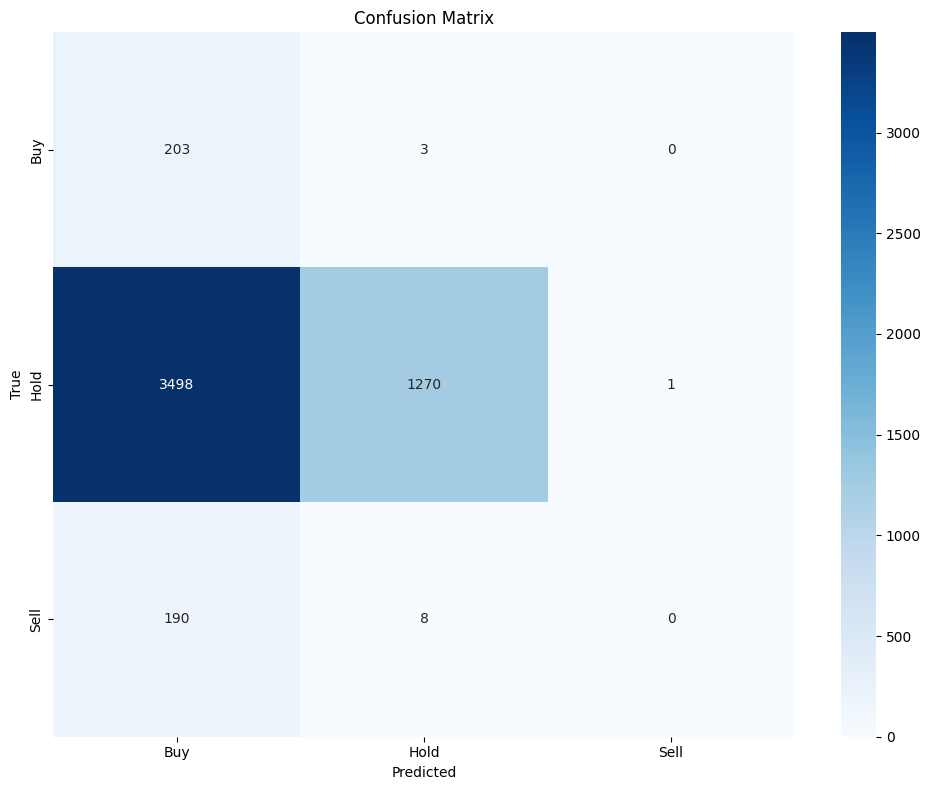


Classification Report:
              precision    recall  f1-score   support

         Buy       0.05      0.99      0.10       206
        Hold       0.99      0.27      0.42      4769
        Sell       0.00      0.00      0.00       198

    accuracy                           0.28      5173
   macro avg       0.35      0.42      0.17      5173
weighted avg       0.92      0.28      0.39      5173



In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Accuracy and Loss

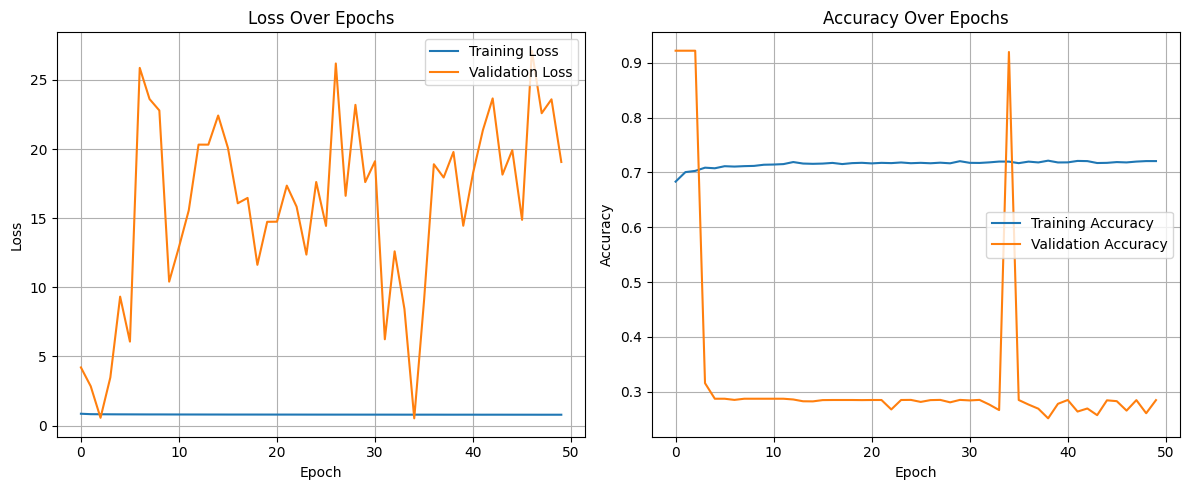

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


It appears that the model fits the training data reasonably well (with relatively stable training loss and accuracy), but it struggles to generalize—evidenced by the validation loss spiking and the validation accuracy hovering at a much lower level. In short, the model is overfitting: it memorizes patterns in the training set but fails to perform consistently on unseen data.

## Testing Performance

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step

Trading Performance on Test Data:
Total PnL (percentage): 12.95%
Absolute PnL: $12,945.25
Annualized Sharpe Ratio: 0.1403


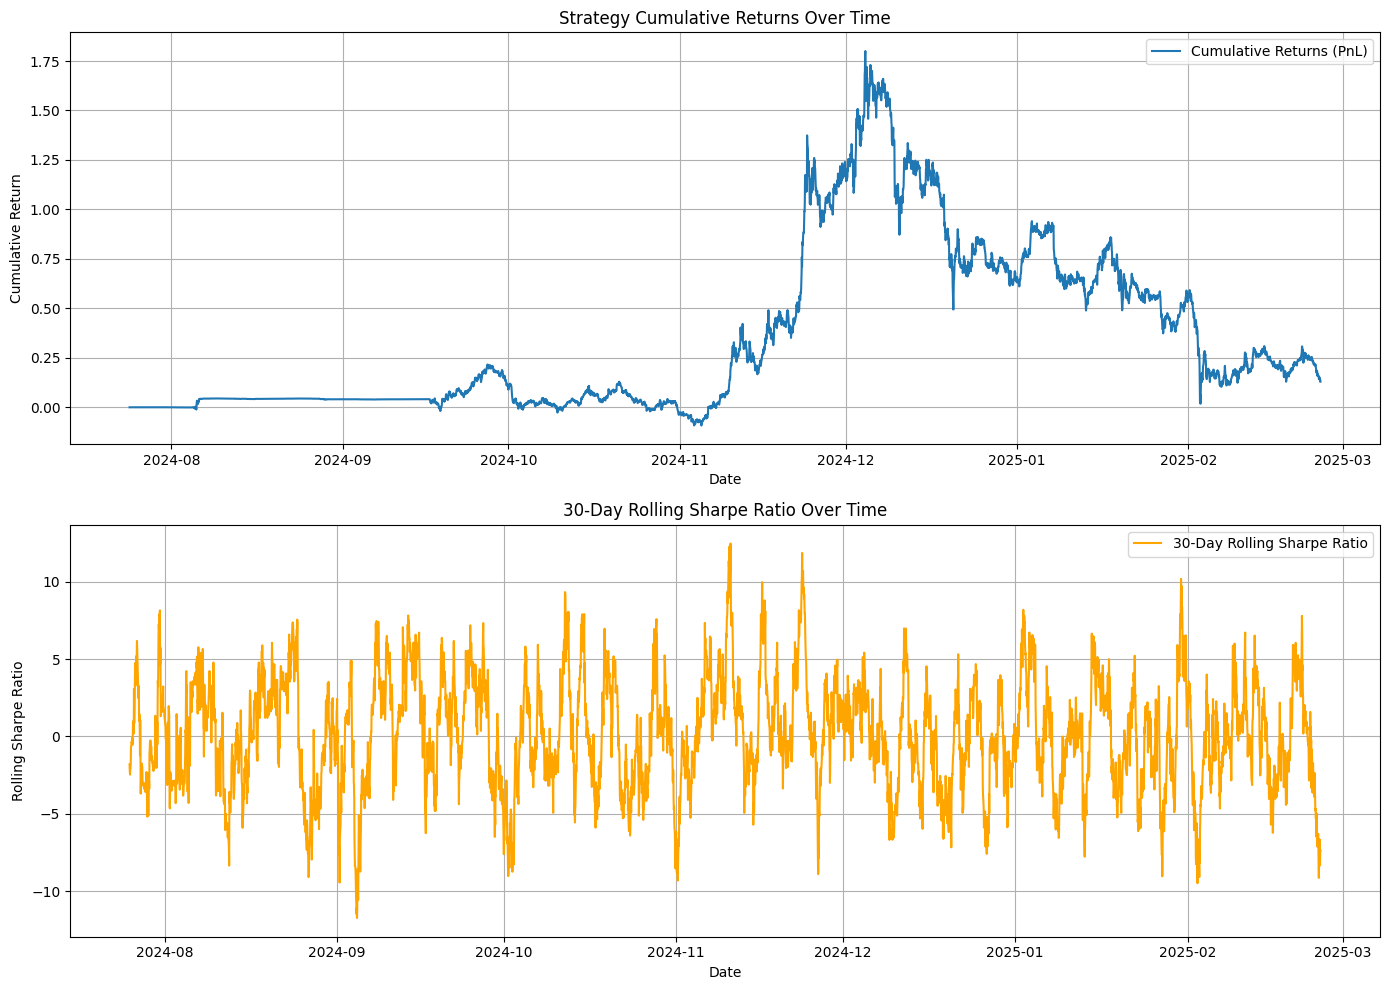

In [ ]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(8760)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [ ]:
Btc_prices = pd.read_parquet('../Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):

    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")



Performance Metrics:
mean_return_annual: 0.6402119398117065
vol_annual: 0.9317502090906096
sharpe_ratio: 0.6871068378257247
sortino_ratio: 0.8362889247354243
max_drawdown: -0.6364439725875854
calmar_ratio: 1.0059202909469604
VaR_95: 0.01457231747917831
CVaR_95: 0.024456728249788284
beta (to BTC): 0.9496918878787641
information_ratio (to BTC): -0.10956659655342403
correlation_with_BTC: 0.5368160398261458
upside_capture_ratio (to BTC): 1.084862044023735
downside_capture_ratio (to BTC): 1.0941931266063065
downside_beta (to BTC): 0.9627306747717281


Overall, these metrics suggest that the strategy is capable of delivering high annualized returns—around 64%—but at the cost of high volatility and significant drawdowns (up to 64%), which means that while the risk-adjusted performance is moderate (with a Sharpe ratio of 0.69 and Sortino ratio of 0.84), we need to be prepared for pronounced highs and lows.

In comparison to Bitcoin, the strategy behaves similarly in market movements (with a beta near 0.95 and moderate correlation of 0.54), capturing a bit more upside when Bitcoin rises (upside capture ratio of 1.08) but also suffering slightly greater losses during downturns (downside capture ratio of 1.09), with an information ratio of -0.11 indicating a small underperformance relative to Bitcoin on a risk-adjusted basis.

## Fama-French Comparison

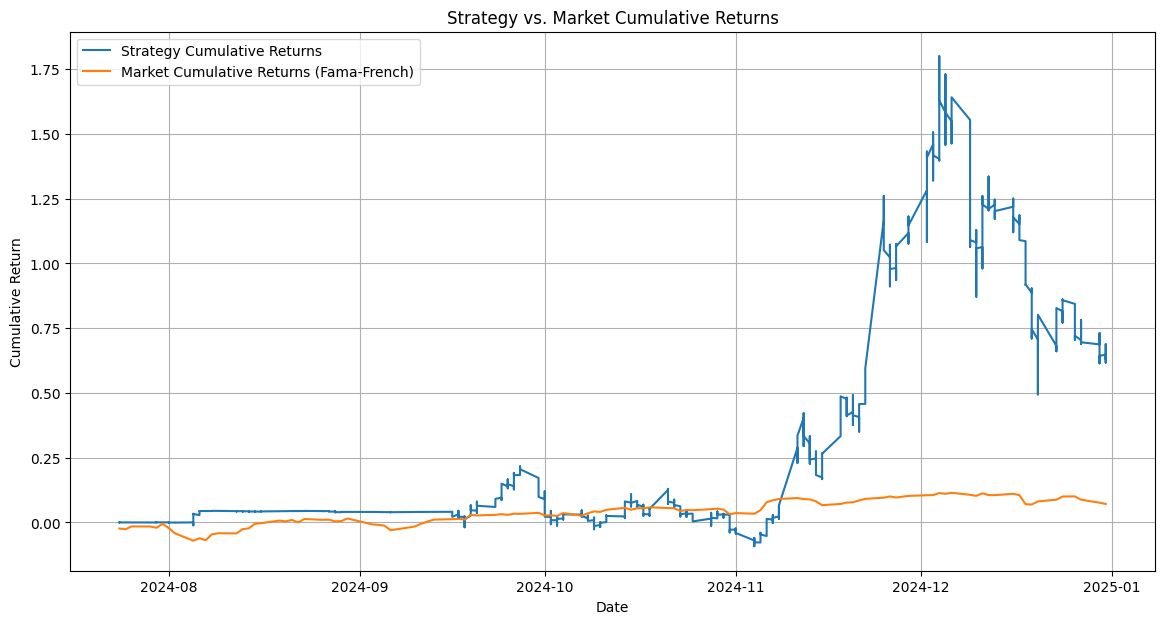

                            OLS Regression Results                            
Dep. Variable:        Strategy_Excess   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.722
Date:                Fri, 14 Mar 2025   Prob (F-statistic):             0.0429
Time:                        22:31:23   Log-Likelihood:                 8718.5
No. Observations:                2677   AIC:                        -1.743e+04
Df Residuals:                    2673   BIC:                        -1.741e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -1.036      0.3

In [ ]:
header_row = None
with open('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


Even though the intercept is not statistically significant, the very low R² in the Fama-French regression indicates that the standard factor exposures (market, size, and value) do not explain much of the strategy’s excess returns, hence this strategy has significant alpha. 

## Average Total PnL, Average Absolute PnL, and Sharpe 

In [ ]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))


Training run 1/10
Train accuracy: 78.36%
Test accuracy: 92.19%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
Run 1 Trading Performance:
  Total PnL (percentage): 0.03%
  Absolute PnL: $26.67
  Annualized Sharpe Ratio: 0.0116

Training run 2/10
Train accuracy: 78.39%
Test accuracy: 92.19%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Run 2 Trading Performance:
  Total PnL (percentage): 0.19%
  Absolute PnL: $188.47
  Annualized Sharpe Ratio: 0.0377

Training run 3/10
Train accuracy: 78.41%
Test accuracy: 92.19%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Run 3 Trading Performance:
  Total PnL (percentage): 0.06%
  Absolute PnL: $63.23
  Annualized Sharpe Ratio: 0.0169

Training run 4/10
Train accuracy: 78.46%
Test accuracy: 92.19%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Run 4 Trading Performance:
  Total PnL (percentage): -0.02%
  Absolute PnL: $-15.02
  Annualized Sharpe Ratio: -0.0333

Training run 5/10
Train accuracy: 78.21%
Test accuracy: 85.02%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step
R

## Loading MATIC Data

In [ ]:
matic_prices = pd.read_parquet('../data/price_data/processed/matic_processed_data.parquet')
matic1_features = pd.read_parquet('../Crypto_QTS_Data_Processed/matic1_chain_processed.parquet').drop(columns=['average_difficulty'])
matic2_features = pd.read_parquet('../Crypto_QTS_Data_Processed/matic2_chain_processed.parquet').drop(columns=['average_base_fee_per_gas','average_difficulty'])
matic_staking = pd.read_parquet('../data/on_chain_data/processed/matic_staking_data.parquet')
matic_tech = pd.read_parquet('../data/data_segmented_tech/matic_data.parquet')

matic_staking.index   = pd.to_datetime(matic_staking.index)
matic1_features.index = pd.to_datetime(matic1_features.index)
matic2_features.index = pd.to_datetime(matic2_features.index)

matic_prices['time_close'] = pd.to_datetime(matic_prices['time_close'])
matic_prices['time_close'] = matic_prices['time_close'].dt.tz_localize('UTC')
matic_prices.set_index('time_close', inplace=True)
matic_prices.index = matic_prices.index + pd.Timedelta(minutes=1)

matic_tech['time_close'] = pd.to_datetime(matic_tech['time_close'])
matic_tech['time_close'] = matic_tech['time_close'].dt.round('min')
matic_tech.set_index('time_close', inplace=True)

df_combined = pd.concat([matic1_features, matic2_features]).sort_index()

common_start = max(matic_staking.index.min(), df_combined.index.min())
common_end   = min(matic_staking.index.max(), df_combined.index.max())

df1_aligned         = matic_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

matic_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

global_start = max(matic_features.index.min(), matic_prices.index.min(), matic_tech.index.min())
global_end   = min(matic_features.index.max(), matic_prices.index.max(), matic_tech.index.max())

matic_features_aligned = matic_features.loc[global_start:global_end]
matic_prices_aligned   = matic_prices.loc[global_start:global_end]

matic_tech_aligned = matic_tech.loc[global_start:global_end].copy()

matic_prices_aligned = matic_prices_aligned[~matic_prices_aligned.index.duplicated(keep='first')]
matic_tech_aligned = matic_tech_aligned[~matic_tech_aligned.index.duplicated(keep='first')]

matic_tech_aligned = matic_tech_aligned.reindex(matic_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
matic_tech_selected = matic_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)


data = matic_features_aligned.join(
    matic_prices_aligned[['price_close']], 
    how='inner'
)


data = data.join(matic_tech_selected, how='left')


lag_cols = [
    'average_gas_limit', 'average_gas_used', 'average_size', 
    'average_total_difficulty', 'active_validators',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [ ]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [ ]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 60.82%
Test accuracy: 41.87%


## Confusion Matrix

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


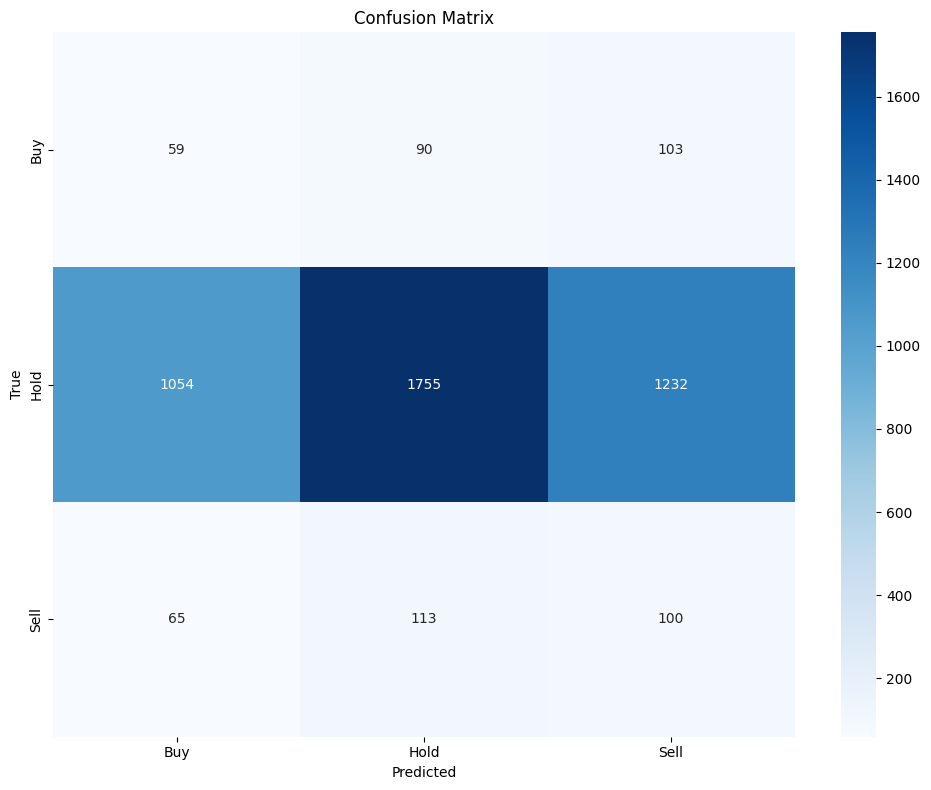


Classification Report:
              precision    recall  f1-score   support

         Buy       0.05      0.23      0.08       252
        Hold       0.90      0.43      0.59      4041
        Sell       0.07      0.36      0.12       278

    accuracy                           0.42      4571
   macro avg       0.34      0.34      0.26      4571
weighted avg       0.80      0.42      0.53      4571



In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Accuracy and Loss

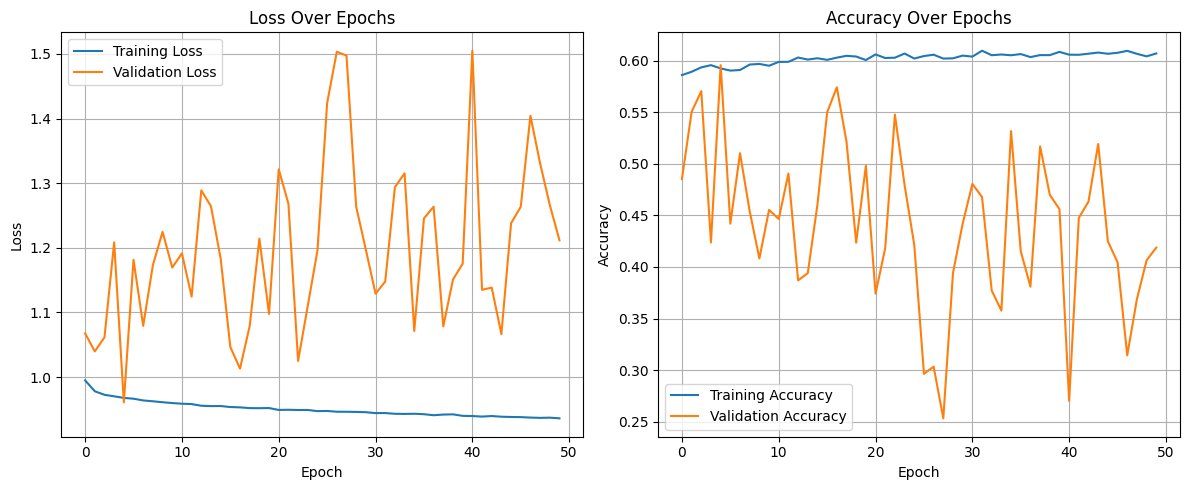

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


The training loss decreases steadily and the training accuracy remains high, but the validation loss and accuracy fluctuate significantly—indicating that while the model is learning the training data effectively, it struggles to generalize and maintain consistent performance on unseen data.

## Testing Performance

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step

Trading Performance on Test Data:
Total PnL (percentage): 11.35%
Absolute PnL: $11,351.29
Annualized Sharpe Ratio: 1.9514


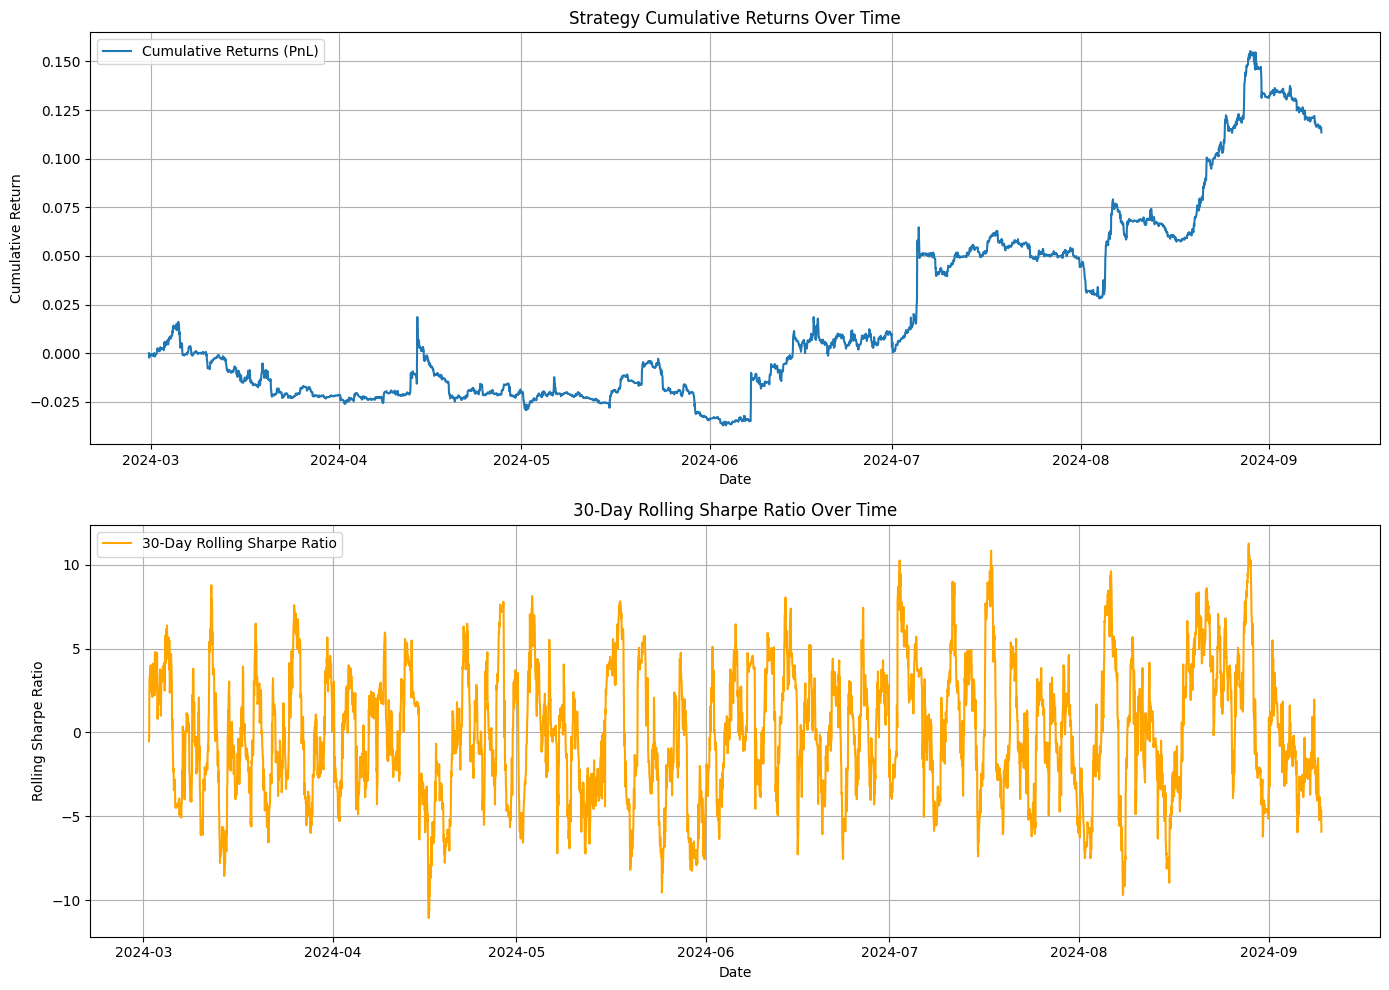

In [ ]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(8760)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [ ]:
Btc_prices = pd.read_parquet('../Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):

    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")



Performance Metrics:
mean_return_annual: 0.21197469532489777
vol_annual: 0.10863892257753677
sharpe_ratio: 1.9511855446983943
sortino_ratio: 2.8134169411311847
max_drawdown: -0.05472711846232414
calmar_ratio: 3.873302698135376
VaR_95: 0.0012577845656778662
CVaR_95: 0.002389885252341628
beta (to BTC): -0.02772398531297813
information_ratio (to BTC): 0.21317920933628345
correlation_with_BTC: -0.14038843455232594
upside_capture_ratio (to BTC): -0.010446092300837415
downside_capture_ratio (to BTC): -0.023529098462126783
downside_beta (to BTC): -0.05913995513320016


These metrics suggest that the strategy generates a solid annual return (about 21%) with relatively low volatility (around 10.9%), producing a strong Sharpe ratio of nearly 2.0 and a Sortino ratio of roughly 2.8. The drawdowns remain modest (about 5.5%), yielding a healthy Calmar ratio near 3.9. Furthermore, the negative beta (-0.028) and slightly negative correlation (-0.14) to Bitcoin indicate the strategy often moves independently or inversely to BTC, providing potential diversification benefits. Its modestly positive information ratio (0.21) reflects some degree of outperformance over Bitcoin on a risk-adjusted basis, while the negative capture ratios imply that the strategy neither participates in BTC’s upside nor suffers much from its downside, helping contain drawdowns.

## Fama-French Comparison

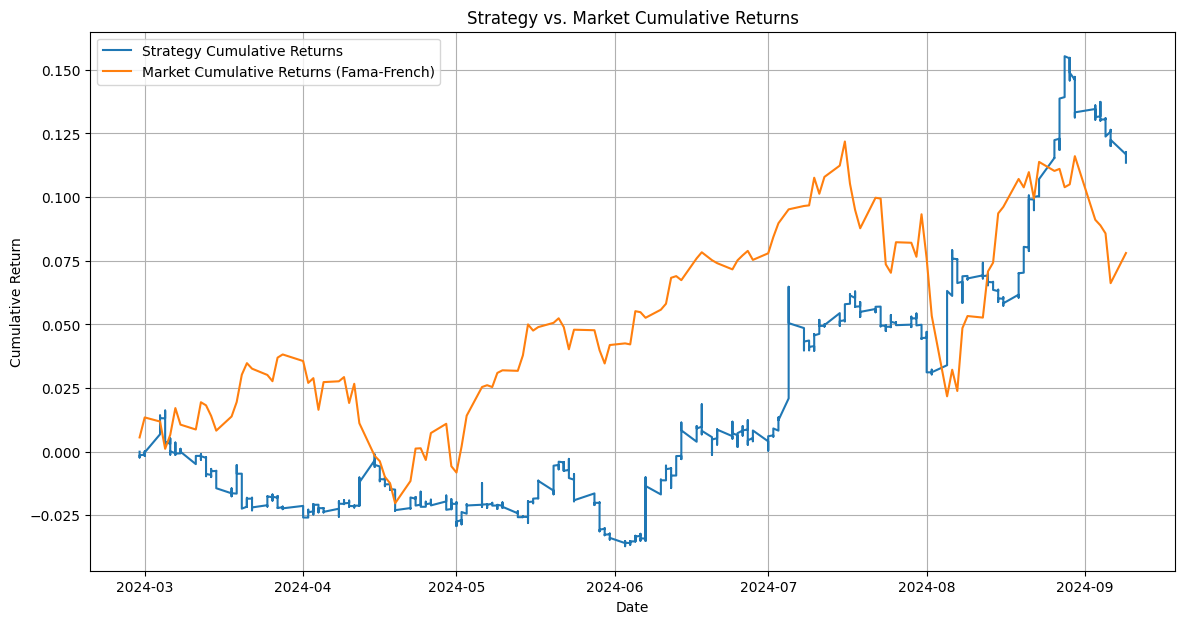

                            OLS Regression Results                            
Dep. Variable:        Strategy_Excess   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8698
Date:                Fri, 14 Mar 2025   Prob (F-statistic):              0.456
Time:                        23:52:46   Log-Likelihood:                 16497.
No. Observations:                3116   AIC:                        -3.299e+04
Df Residuals:                    3112   BIC:                        -3.296e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002   2.19e-05     -8.062      0.0

In [ ]:
header_row = None
with open('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


It appears that the market generally outperforms the strategy particularly after mid-2024. The Fama-French regression results confirm that the standard factors explain virtually none of the strategy’s excess returns (R-squared ≈ 0.001), and none of the factor loadings are statistically significant. Interestingly, the intercept is negative (-0.0002) yet highly significant, suggesting that, after controlling for these factors, the strategy’s average excess return is slightly negative. In other words, the Fama-French model fails to account for the strategy’s performance drivers, which appear to be unrelated to conventional factors.

## Average Total PnL, Average Absolute PnL, and Sharpe 

In [ ]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))


Training run 1/10
Train accuracy: 70.48%
Test accuracy: 87.81%
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step
Run 1 Trading Performance:
  Total PnL (percentage): 2.26%
  Absolute PnL: $2,257.19
  Annualized Sharpe Ratio: 0.1632

Training run 2/10
Train accuracy: 70.17%
Test accuracy: 85.56%
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
Run 2 Trading Performance:
  Total PnL (percentage): 17.35%
  Absolute PnL: $17,346.80
  Annualized Sharpe Ratio: 0.7593

Training run 3/10
Train accuracy: 69.87%
Test accuracy: 72.68%
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step
Run 3 Trading Performance:
  Total PnL (percentage): 7.94%
  Absolute PnL: $7,941.63
  Annualized Sharpe Ratio: 0.2541

Training run 4/10
Train accuracy: 70.55%
Test accuracy: 87.79%
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step
Run 4 Trading Performance:
  Total PnL (percentage): 3.63%
  Absolute PnL: $3,629.12
  Annualized Sharpe Ratio: 0.3044

Training run 5/10
Train accuracy: 70.41%
Test accuracy: 78.98%
143/143 ━━━━━━━━━━━━━━━━━━━━ 0

## Loading NEAR Data

In [ ]:
near_prices  = pd.read_parquet('../Crypto_QTS_Data_Processed/near_price_processed.parquet')
near_staking = pd.read_parquet('../data/on_chain_data/processed/near_staking_data.parquet')
near_tech    = pd.read_parquet('../data/data_segmented_tech/near_data.parquet')

near_staking.index = pd.to_datetime(near_staking.index)

near_prices.index = pd.to_datetime(near_prices.index)

near_tech['time_close'] = pd.to_datetime(near_tech['time_close'])
near_tech['time_close'] = near_tech['time_close'].dt.round('min')
near_tech.set_index('time_close', inplace=True)

near_features = near_staking.copy()

global_start = max(near_features.index.min(), near_prices.index.min(), near_tech.index.min())
global_end   = min(near_features.index.max(), near_prices.index.max(), near_tech.index.max())

near_features_aligned = near_features.loc[global_start:global_end]
near_prices_aligned   = near_prices.loc[global_start:global_end]

near_tech_aligned = near_tech.loc[global_start:global_end].copy()

near_prices_aligned = near_prices_aligned[~near_prices_aligned.index.duplicated(keep='first')]
near_tech_aligned   = near_tech_aligned[~near_tech_aligned.index.duplicated(keep='first')]

near_tech_aligned = near_tech_aligned.reindex(near_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
near_tech_selected = near_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

data = near_features_aligned.join(
    near_prices_aligned[['price_close']], 
    how='inner'
)

data = data.join(near_tech_selected, how='left')

lag_cols = [ 
    'real_reward_rate',
    'staked_tokens', 'staking_ratio',
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [ ]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [ ]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 65.14%
Test accuracy: 52.89%


## Confusion Matrix

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step


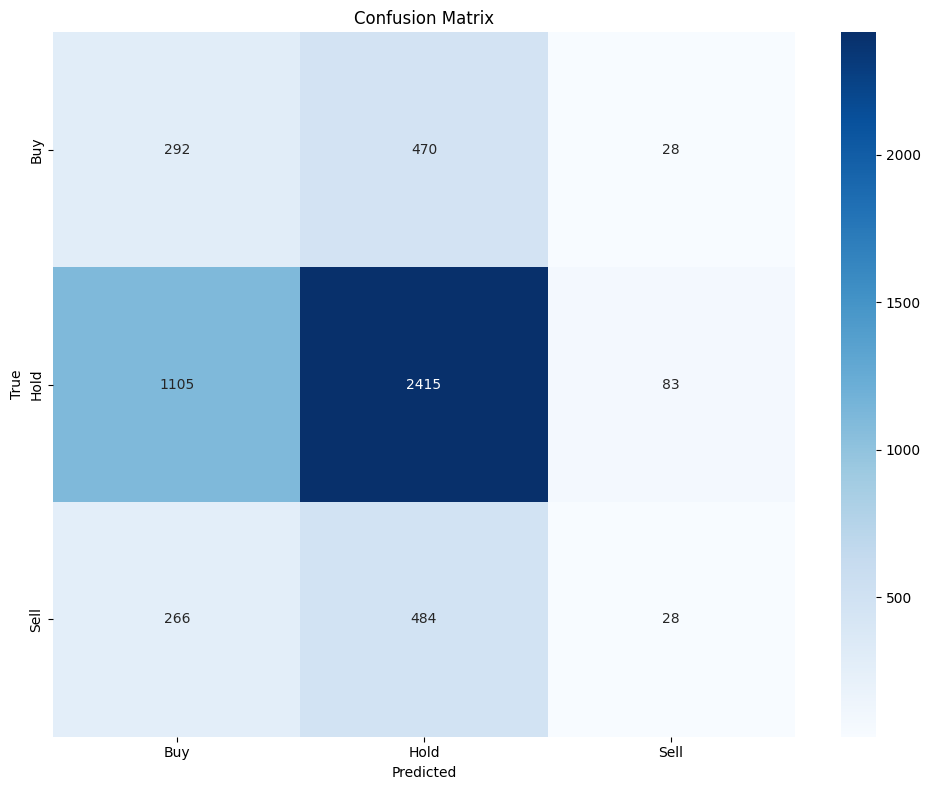


Classification Report:
              precision    recall  f1-score   support

         Buy       0.18      0.37      0.24       790
        Hold       0.72      0.67      0.69      3603
        Sell       0.20      0.04      0.06       778

    accuracy                           0.53      5171
   macro avg       0.36      0.36      0.33      5171
weighted avg       0.56      0.53      0.53      5171



In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Accuracy and Loss

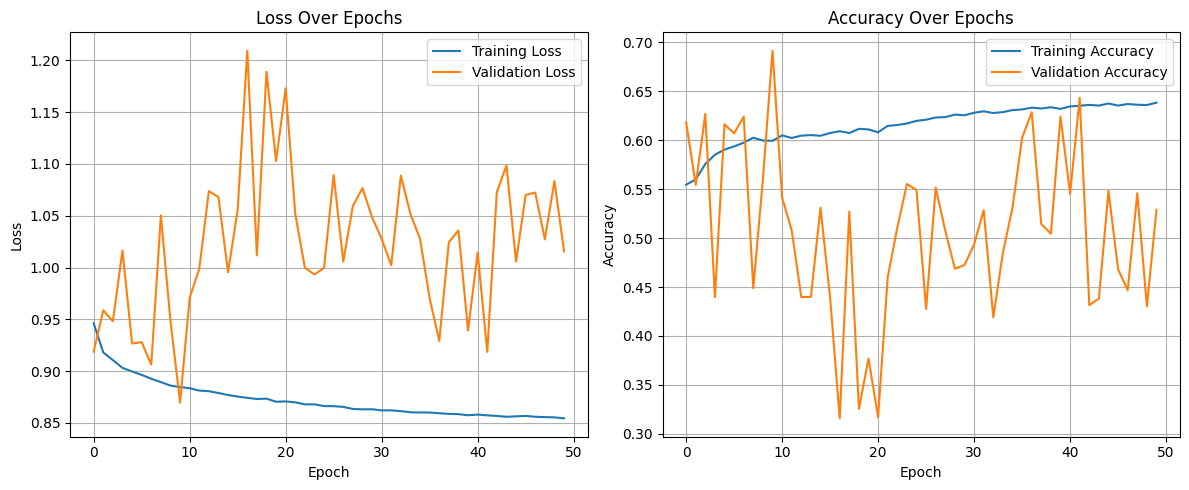

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


From these plots, the model’s training performance steadily improves—loss declines and accuracy climbs—while the validation loss remains volatile and the validation accuracy fluctuates widely. This discrepancy indicates that the model is likely overfitting: it learns patterns in the training data well but fails to generalize reliably to unseen data.

## Testing Performance

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step

Trading Performance on Test Data:
Total PnL (percentage): 13.78%
Absolute PnL: $13,784.90
Annualized Sharpe Ratio: 1.7736


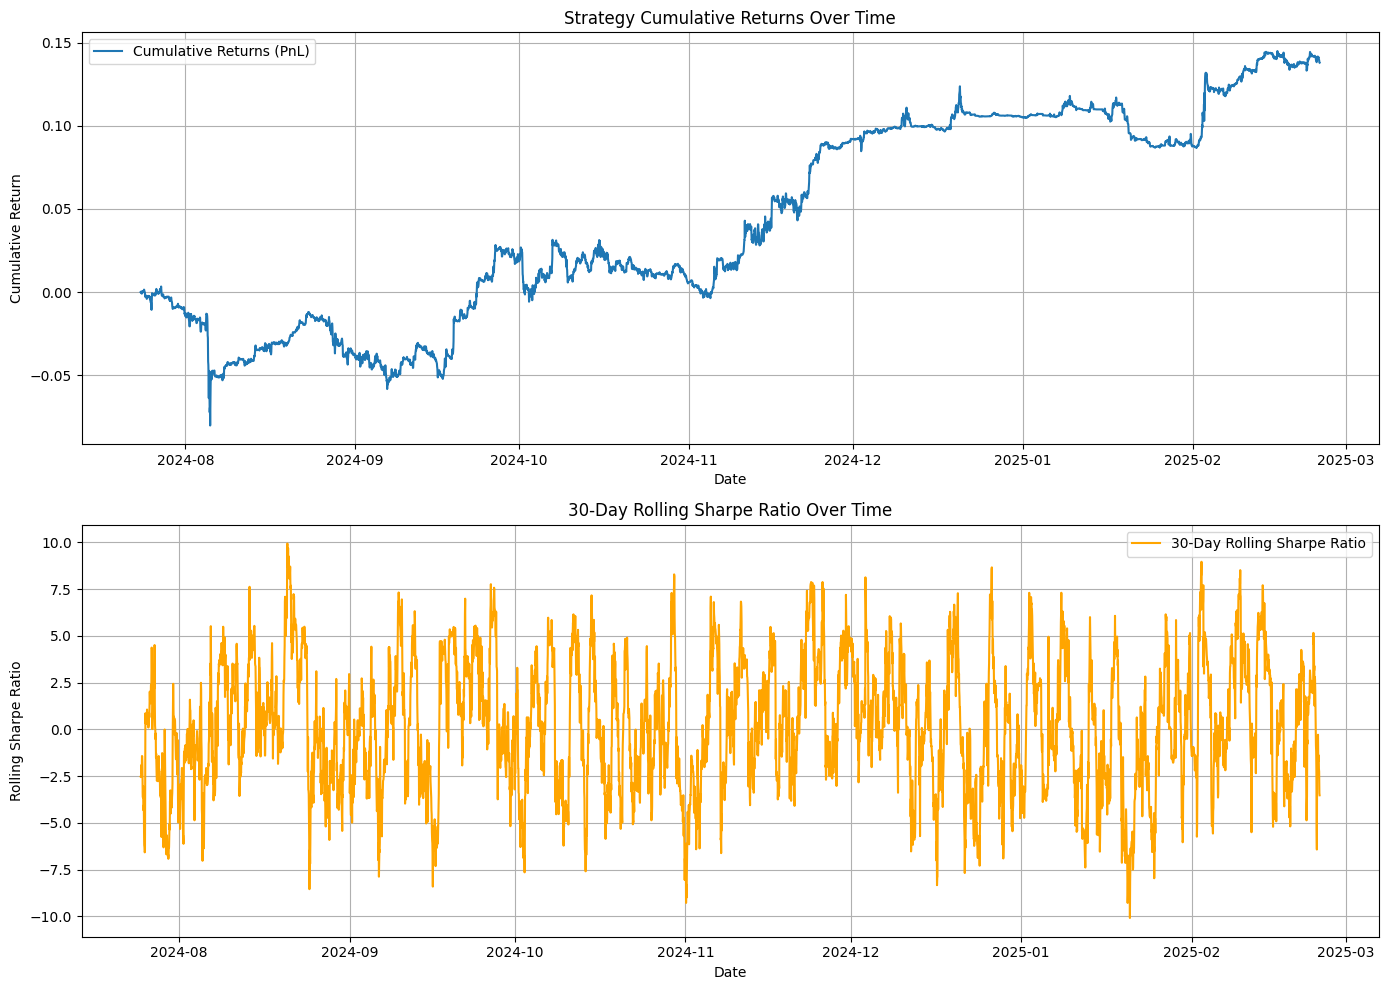

In [ ]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(8760)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [ ]:
Btc_prices = pd.read_parquet('../Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):

    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")



Performance Metrics:
mean_return_annual: 0.2270018309354782
vol_annual: 0.12800101604776173
sharpe_ratio: 1.7734377268597286
sortino_ratio: 2.2352010046161603
max_drawdown: -0.08327823132276535
calmar_ratio: 2.7258243560791016
VaR_95: 0.0017822468071244657
CVaR_95: 0.003095462452620268
beta (to BTC): 0.09319143169188256
information_ratio (to BTC): -1.0922316410382387
correlation_with_BTC: 0.38343520562583366
upside_capture_ratio (to BTC): 0.10493966131529438
downside_capture_ratio (to BTC): 0.09566330422046422
downside_beta (to BTC): 0.07579062885532731


These metrics indicate that the strategy achieves a solid annual return of roughly 22.7% with moderate volatility (around 12.8%), yielding a strong Sharpe ratio of 1.77 and a Sortino ratio above 2.2. The maximum drawdown is relatively contained (about 8.3%), resulting in a healthy Calmar ratio near 2.73. Though it has a moderate correlation (0.38) and a low beta (0.09) to Bitcoin—suggesting partial independence from BTC’s price movements—the negative information ratio (-1.09) implies underperformance relative to Bitcoin on a risk-adjusted basis. Nonetheless, its low upside (0.10) and downside (0.10) capture ratios help limit drawdowns, but also cap participation in Bitcoin’s rallies.

## Fama-French Comparison

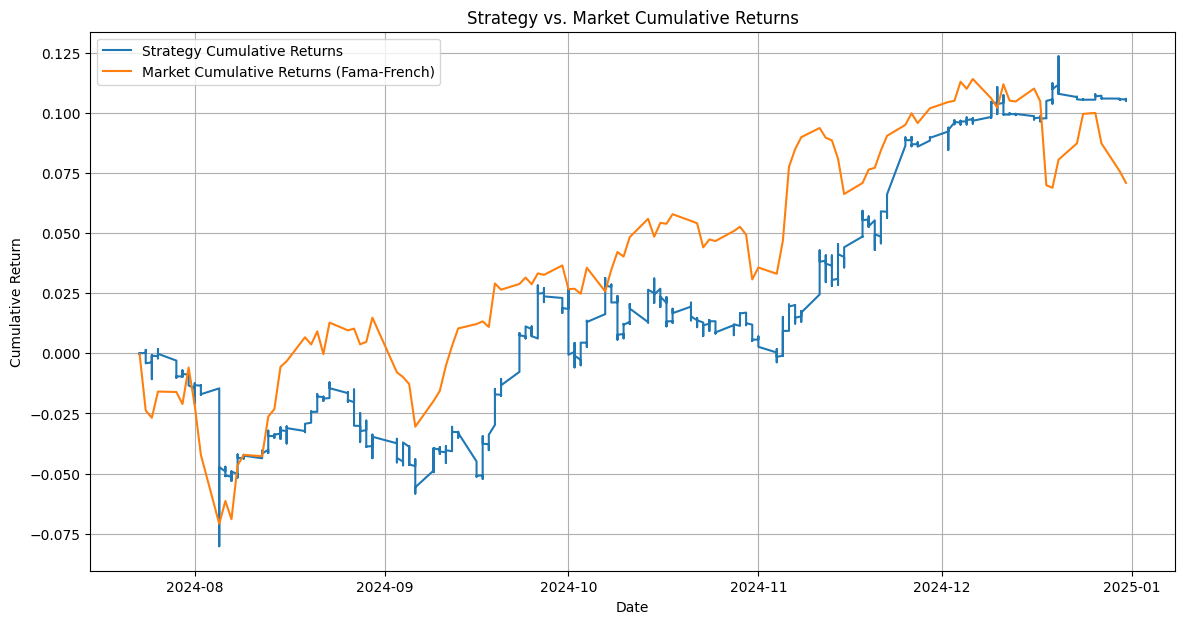

                            OLS Regression Results                            
Dep. Variable:        Strategy_Excess   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     5.278
Date:                Sat, 15 Mar 2025   Prob (F-statistic):            0.00125
Time:                        00:59:31   Log-Likelihood:                 13470.
No. Observations:                2692   AIC:                        -2.693e+04
Df Residuals:                    2688   BIC:                        -2.691e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002   3.14e-05     -5.364      0.0

In [ ]:
header_row = None
with open('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


The strategy largely tracks the Fama-French market proxy through late 2024 into early 2025, sometimes lagging but occasionally catching up. The regression results show that the market factor (Mkt_RF) is the only significant driver (coefficient ≈ 0.012), while size (SMB) and value (HML) are not, and the very low R² (0.006) indicates that these three factors collectively explain almost none of the strategy’s excess returns.

## Average Total PnL, Average Absolute PnL, and Sharpe 

In [ ]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))


Training run 1/10
Train accuracy: 71.80%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
Run 1 Trading Performance:
  Total PnL (percentage): -0.12%
  Absolute PnL: $-117.42
  Annualized Sharpe Ratio: -0.0911

Training run 2/10
Train accuracy: 72.55%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
Run 2 Trading Performance:
  Total PnL (percentage): -0.11%
  Absolute PnL: $-105.88
  Annualized Sharpe Ratio: -0.0997

Training run 3/10
Train accuracy: 72.41%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step
Run 3 Trading Performance:
  Total PnL (percentage): -0.01%
  Absolute PnL: $-6.59
  Annualized Sharpe Ratio: -0.0079

Training run 4/10
Train accuracy: 72.50%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
Run 4 Trading Performance:
  Total PnL (percentage): -0.34%
  Absolute PnL: $-338.69
  Annualized Sharpe Ratio: -0.3568

Training run 5/10
Train accuracy: 72.34%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0

## Loading SOL Data

In [ ]:
sol_prices = pd.read_parquet('../data/price_data/processed/sol_processed_data.parquet')
sol_features = pd.read_parquet('../Crypto_QTS_Data_Processed/sol_chain_processed.parquet')
sol_staking = pd.read_parquet('../data/on_chain_data/processed/sol_staking_data.parquet')
sol_tech = pd.read_parquet('../data/data_segmented_tech/sol_data.parquet')

sol_staking.index   = pd.to_datetime(sol_staking.index)
sol_features.index = pd.to_datetime(sol_features.index)

sol_prices['time_close'] = pd.to_datetime(sol_prices['time_close'])
sol_prices['time_close'] = sol_prices['time_close'].dt.tz_localize('UTC')
sol_prices.set_index('time_close', inplace=True)
sol_prices.index = sol_prices.index + pd.Timedelta(minutes=1)

sol_tech['time_close'] = pd.to_datetime(sol_tech['time_close'])
sol_tech['time_close'] = sol_tech['time_close'].dt.round('min')
sol_tech.set_index('time_close', inplace=True)

df_combined = pd.concat([sol_features, sol_features]).sort_index()

common_start = max(sol_staking.index.min(), df_combined.index.min())
common_end   = min(sol_staking.index.max(), df_combined.index.max())

df1_aligned         = sol_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

sol_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

global_start = max(sol_features.index.min(), sol_prices.index.min(), sol_tech.index.min())
global_end   = min(sol_features.index.max(), sol_prices.index.max(), sol_tech.index.max())

sol_features_aligned = sol_features.loc[global_start:global_end]
sol_prices_aligned   = sol_prices.loc[global_start:global_end]

sol_tech_aligned = sol_tech.loc[global_start:global_end].copy()

sol_prices_aligned = sol_prices_aligned[~sol_prices_aligned.index.duplicated(keep='first')]
sol_tech_aligned = sol_tech_aligned[~sol_tech_aligned.index.duplicated(keep='first')]

sol_tech_aligned = sol_tech_aligned.reindex(sol_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
sol_tech_selected = sol_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)


data = sol_features_aligned.join(
    sol_prices_aligned[['price_close']], 
    how='inner'
)


data = data.join(sol_tech_selected, how='left')


lag_cols = [
    'average_total_transactions', 'average_successful_transactions', 'average_failed_transactions', 
    'average_total_vote_transactions', 'average_total_non_vote_transactions','average_successful_vote_transactions','average_successful_non_vote_transactions',
    'average_failed_vote_transactions', 'average_failed_non_vote_transactions',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets','active_validators','real_reward_rate'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [ ]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [ ]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 58.69%
Test accuracy: 25.39%


## Confusion Matrix

295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step


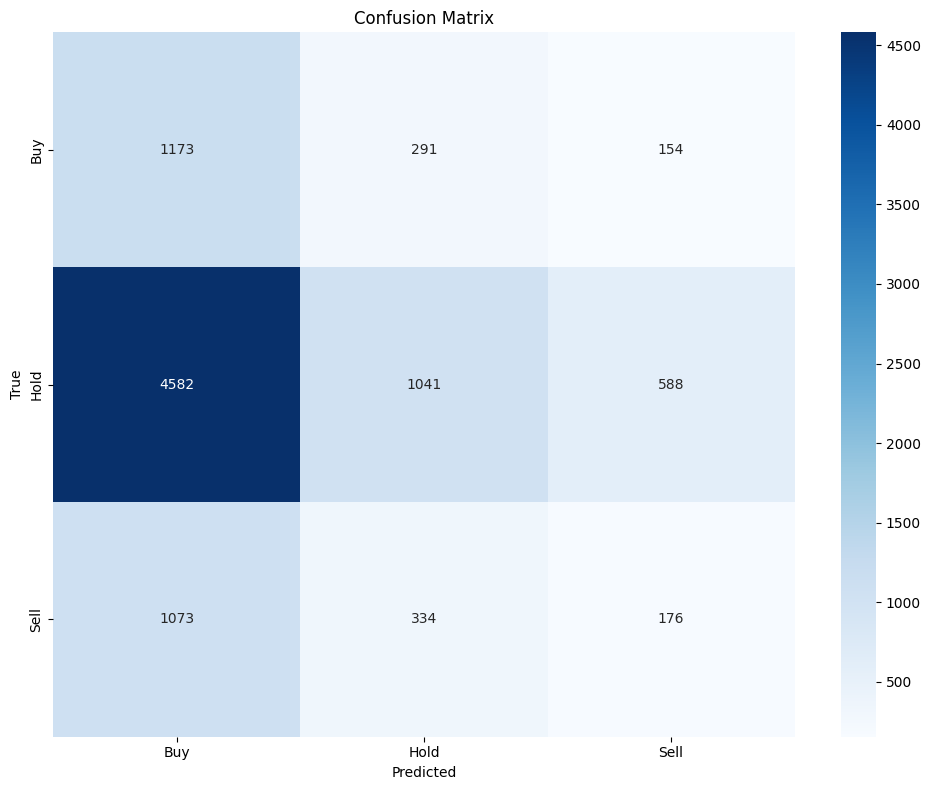


Classification Report:
              precision    recall  f1-score   support

         Buy       0.17      0.72      0.28      1618
        Hold       0.62      0.17      0.26      6211
        Sell       0.19      0.11      0.14      1583

    accuracy                           0.25      9412
   macro avg       0.33      0.33      0.23      9412
weighted avg       0.47      0.25      0.25      9412



In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Accuracy and Loss

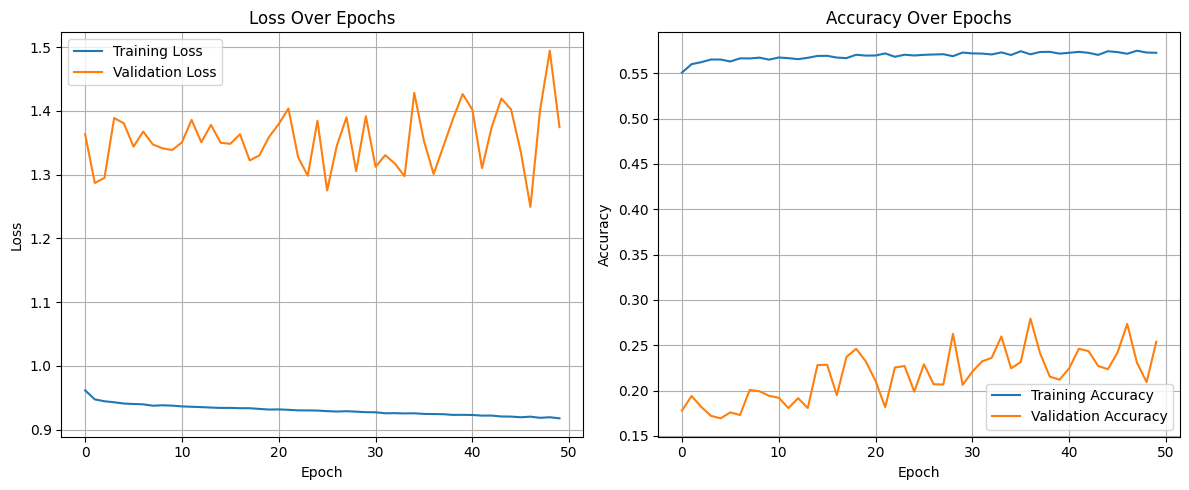

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Despite steady improvement on the training set (loss trending down and accuracy hovering around 55%), the validation loss remains high and the validation accuracy is notably low and volatile—indicating that the model overfits the training data and fails to generalize effectively to unseen data.

## Testing Performance

295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step

Trading Performance on Test Data:
Total PnL (percentage): -0.98%
Absolute PnL: $-984.25
Annualized Sharpe Ratio: 0.0854


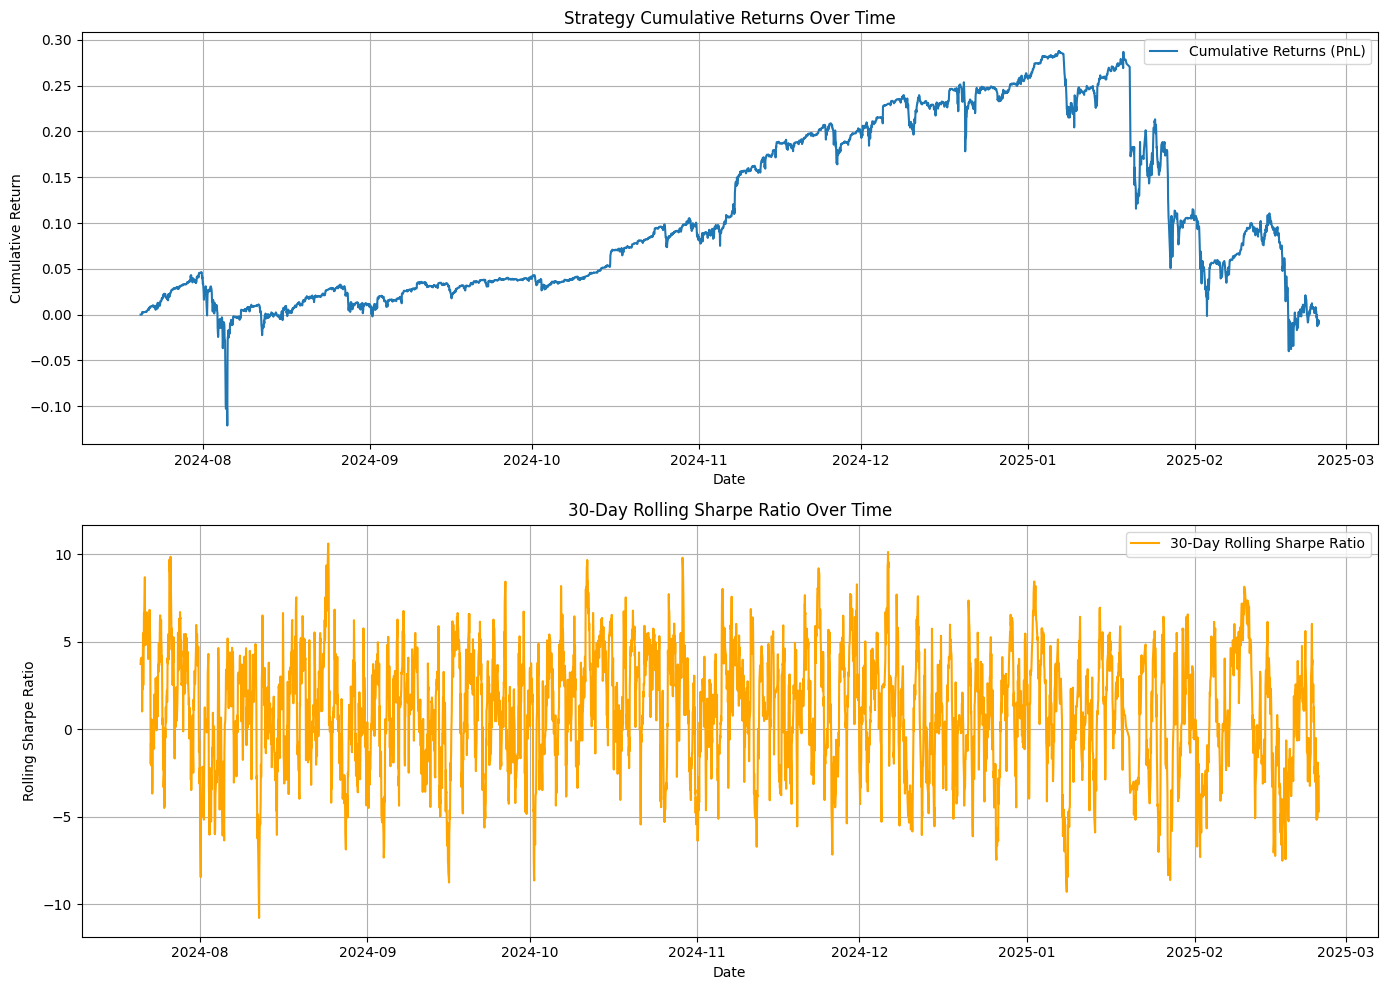

In [ ]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(8760)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [ ]:
Btc_prices = pd.read_parquet('../Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):
    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
        
    asset_returns = asset_returns[~asset_returns.index.duplicated(keep='first')]
    benchmark_returns = benchmark_returns[~benchmark_returns.index.duplicated(keep='first')]
    
    benchmark_returns = benchmark_returns.reindex(asset_returns.index, method='nearest')
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
        
    returns = returns[~returns.index.duplicated(keep='first')]
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
            
        benchmark_returns = benchmark_returns[~benchmark_returns.index.duplicated(keep='first')]
        benchmark_returns = benchmark_returns.reindex(returns.index, method='nearest')
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")


Performance Metrics:
mean_return_annual: 0.04189331457018852
vol_annual: 0.3470718431557249
sharpe_ratio: 0.12070502230684194
sortino_ratio: 0.12826131599233098
max_drawdown: -0.25457748770713806
calmar_ratio: 0.16456016898155212
VaR_95: 0.003761597443372011
CVaR_95: 0.00882421713322401
beta (to BTC): 0.3031362545453595
information_ratio (to BTC): -2.7933047421801596
correlation_with_BTC: 0.4378072370486742
upside_capture_ratio (to BTC): 0.26428013349397933
downside_capture_ratio (to BTC): 0.28557827752266557
downside_beta (to BTC): 0.2943679104215417


The strategy yields a modest annual return (about 4.2%) against relatively high volatility (34.7%), resulting in a low Sharpe ratio (0.12) and Sortino ratio (0.13). The drawdowns are not negligible (max drawdown of around 25.5%), giving a Calmar ratio of 0.16, which underscores that the returns are overshadowed by periods of loss. With a beta of 0.30 and correlation of 0.44 to Bitcoin, the strategy partially tracks BTC’s movements, but the negative information ratio (-2.79) indicates underperformance on a risk-adjusted basis. Meanwhile, the low upside (0.26) and downside (0.29) capture ratios suggest that it neither participates significantly in Bitcoin’s rallies nor suffers fully during its downturns—yet still fails to deliver robust risk-adjusted returns.

## Fama-French Comparison

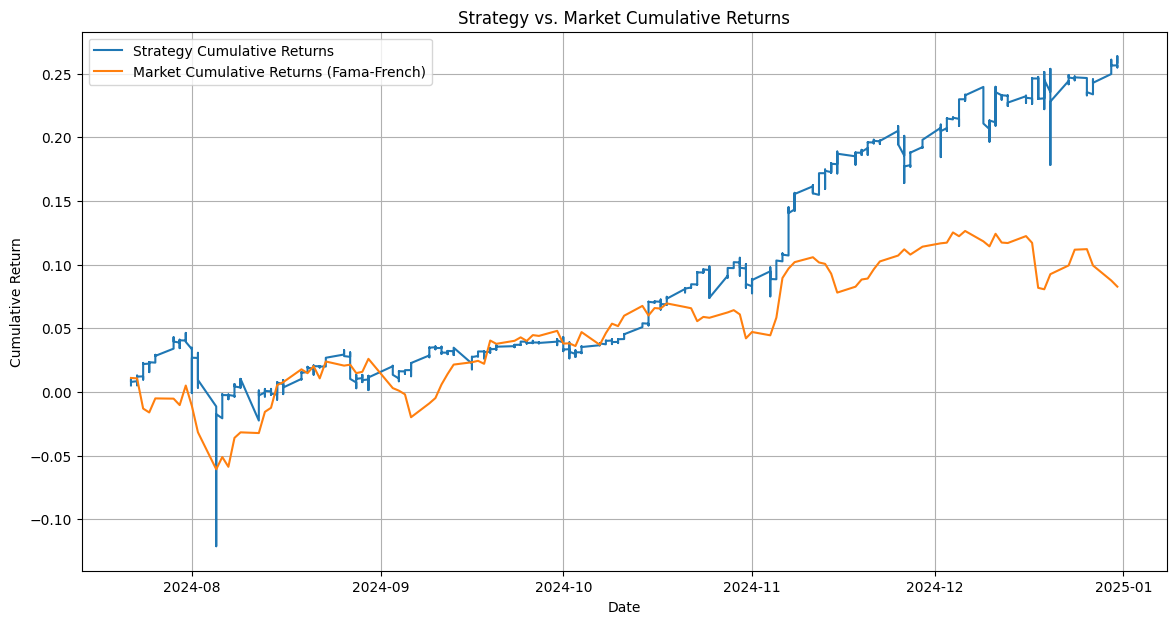

                            OLS Regression Results                            
Dep. Variable:        Strategy_Excess   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5556
Date:                Fri, 14 Mar 2025   Prob (F-statistic):              0.644
Time:                        23:52:14   Log-Likelihood:                 24476.
No. Observations:                5192   AIC:                        -4.894e+04
Df Residuals:                    5188   BIC:                        -4.892e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002   3.02e-05     -5.356      0.0

In [ ]:
header_row = None
with open('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('Data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


The strategy’s cumulative return far exceeds the Fama-French market proxy. However, the regression results (R² ≈ 0.0) indicates that none of the three standard factors meaningfully explain the strategy’s excess returns. The model attributes neither the strategy’s outperformance nor any unique factor exposure to traditional Fama-French components, suggesting that its strong performance arises from sources not captured by market, size, or value.

## Average Total PnL, Average Absolute PnL, and Sharpe 

In [ ]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))


Training run 1/10
Train accuracy: 80.98%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step
Run 1 Trading Performance:
  Total PnL (percentage): 0.57%
  Absolute PnL: $574.39
  Annualized Sharpe Ratio: 0.0226

Training run 2/10
Train accuracy: 81.93%
Test accuracy: 65.97%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step
Run 2 Trading Performance:
  Total PnL (percentage): 4.58%
  Absolute PnL: $4,577.83
  Annualized Sharpe Ratio: 0.1978

Training run 3/10
Train accuracy: 81.95%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
Run 3 Trading Performance:
  Total PnL (percentage): 3.78%
  Absolute PnL: $3,778.02
  Annualized Sharpe Ratio: 0.1573

Training run 4/10
Train accuracy: 81.94%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step
Run 4 Trading Performance:
  Total PnL (percentage): -0.31%
  Absolute PnL: $-307.27
  Annualized Sharpe Ratio: -0.0012

Training run 5/10
Train accuracy: 80.59%
Test accuracy: 65.99%
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 6

In [ ]:
dfs, price_dfs = pm.prep_data()
#stop_loss_pct = 100000000
starting_capital = 100_000
coin_names = coin_names = list(dfs.keys())
portfolio_size = len(coin_names)
transaction_cost = 0.000
#transaction_cost = 0.001
     
results, stop_loss = pm.calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names, transaction_cost)
     
pnl, cumulative_capital = pm.calculate_pnl(results, starting_capital)

pm.display_end_pnl_by_coin(results, starting_capital, plot = True)

NameError: name 'pm' is not defined

In [ ]:
start = pd.to_datetime('2024-02-29 16:00:00+00:00')
end = pd.to_datetime('2025-02-24 22:00:00+00:00')

In [ ]:
rets_AVAX = results['AVAX'].set_index('Date')
rets_AVAX['subsector value'] = rets_AVAX['Cash Holdings'] + rets_AVAX['Coin Value']

backfill_index = pd.date_range(start=start, end=rets_AVAX.index[0], freq='H', inclusive='left')

# Create a Series with the fill value and the backfill index
backfill_series = pd.Series(20_000, index=backfill_index)

# Concatenate the backfill Series and the original Series
rets_AVAX_full = pd.concat([backfill_series, rets_AVAX['subsector value']])

# Create a DatetimeIndex for the forward-fill range
forwardfill_index = pd.date_range(start=rets_AVAX.index[-1], end=end, freq='H', inclusive='right')

# Get the latest observed value
latest_value = rets_AVAX_full.iloc[-1]

# Create a Series with the latest value and the forward-fill index
forwardfill_series = pd.Series(latest_value, index=forwardfill_index)

# Concatenate the original Series and the forward-fill Series
AVAX = pd.concat([rets_AVAX_full, forwardfill_series])
AVAX

In [ ]:
rets_DOT = results['DOT'].set_index('Date')
rets_DOT['subsector value'] = rets_DOT['Cash Holdings'] + rets_DOT['Coin Value']

backfill_index = pd.date_range(start=start, end=rets_DOT.index[0], freq='H', inclusive='left')

# Create a Series with the fill value and the backfill index
backfill_series = pd.Series(20_000, index=backfill_index)

# Concatenate the backfill Series and the original Series
rets_DOT_full = pd.concat([backfill_series, rets_DOT['subsector value']])

# Create a DatetimeIndex for the forward-fill range
forwardfill_index = pd.date_range(start=rets_DOT.index[-1], end=end, freq='H', inclusive='right')

# Get the latest observed value
latest_value = rets_DOT_full.iloc[-1]

# Create a Series with the latest value and the forward-fill index
forwardfill_series = pd.Series(latest_value, index=forwardfill_index)

# Concatenate the original Series and the forward-fill Series
DOT = rets_DOT_full
DOT

In [ ]:
rets_SOL = results['SOL'].set_index('Date')
rets_SOL['subsector value'] = rets_SOL['Cash Holdings'] + rets_SOL['Coin Value']

backfill_index = pd.date_range(start=start, end=rets_SOL.index[0], freq='H', inclusive='left')

# Create a Series with the fill value and the backfill index
backfill_series = pd.Series(20_000, index=backfill_index)

# Concatenate the backfill Series and the original Series
rets_SOL_full = pd.concat([backfill_series, rets_SOL['subsector value']])

# Create a DatetimeIndex for the forward-fill range
forwardfill_index = pd.date_range(start=rets_SOL.index[-1], end=end, freq='H', inclusive='right')

# Get the latest observed value
latest_value = rets_SOL_full.iloc[-1]

# Create a Series with the latest value and the forward-fill index
forwardfill_series = pd.Series(latest_value, index=forwardfill_index)

# Concatenate the original Series and the forward-fill Series
SOL = pd.concat([rets_SOL_full, forwardfill_series])
SOL

In [ ]:
rets_MATIC = results['MATIC'].set_index('Date')
rets_MATIC['subsector value'] = rets_MATIC['Cash Holdings'] + rets_MATIC['Coin Value']

backfill_index = pd.date_range(start=start, end=rets_MATIC.index[0], freq='H', inclusive='left')

# Create a Series with the fill value and the backfill index
backfill_series = pd.Series(20_000, index=backfill_index)

# Concatenate the backfill Series and the original Series
rets_MATIC_full = rets_MATIC['subsector value']

# Create a DatetimeIndex for the forward-fill range
forwardfill_index = pd.date_range(start=rets_MATIC.index[-1], end=end, freq='H', inclusive='right')

# Get the latest observed value
latest_value = rets_MATIC_full.iloc[-1]

# Create a Series with the latest value and the forward-fill index
forwardfill_series = pd.Series(latest_value, index=forwardfill_index)

# Concatenate the original Series and the forward-fill Series
MATIC = pd.concat([rets_MATIC_full, forwardfill_series])
MATIC

In [ ]:
rets_NEAR = results['NEAR'].set_index('Date')
rets_NEAR['subsector value'] = rets_NEAR['Cash Holdings'] + rets_NEAR['Coin Value']

backfill_index = pd.date_range(start=start, end=rets_NEAR.index[0], freq='H', inclusive='left')

# Create a Series with the fill value and the backfill index
backfill_series = pd.Series(20_000, index=backfill_index)

# Concatenate the backfill Series and the original Series
rets_NEAR_full = pd.concat([backfill_series, rets_NEAR['subsector value']])

# Create a DatetimeIndex for the forward-fill range
forwardfill_index = pd.date_range(start=rets_NEAR.index[-1], end=end, freq='H', inclusive='right')

# Get the latest observed value
latest_value = rets_NEAR_full.iloc[-1]

# Create a Series with the latest value and the forward-fill index
forwardfill_series = pd.Series(latest_value, index=forwardfill_index)

# Concatenate the original Series and the forward-fill Series
NEAR = pd.concat([rets_NEAR_full, forwardfill_series])
NEAR

In [ ]:
rets = []

for i in range(len(NEAR)):
  try:
    rets.append(NEAR.iloc[i] + DOT.iloc[i] + SOL.iloc[i] + MATIC.iloc[i] + AVAX.iloc[i])
  except:
    break

pd.Series(rets).pct_change()[1:].plot()


In [ ]:
pd.Series(rets).diff().cumsum()[1:].plot()

In [ ]:
Btc_prices = pd.read_parquet('Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):

    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=pd.Series(rets).pct_change()[1:],
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")

In [ ]:
performance_metrics_df = pd.DataFrame(0, index=performance_metrics.keys(), columns=['Performance Metrics'])
for k, v in performance_metrics.items():
    performance_metrics_df.loc[k, 'Performance Metrics'] = v 
performance_metrics_df.style.format("{:.2f}")